# Анализ продуктовой стратегии маркетплейса и пути улучшений

Маркетплейс недавно вышел на рынок и занимается продажей новых товаров из Бразилии, которые только начинают поступать в продажу. Однако выручка уже несколько месяцев остается на одном уровне, что вызывает обеспокоенность у продакт-менеджера. 

Продакт-менеджер предложил полную свободу действий в решении данной проблемы, главное условие — рост ключевых метрик без ущерба для клиентского опыта.

## 1. Исследовательский анализ данных (EDA)

In [2]:
# Импортируем необходимые библиотеки 
import pandas as pd
import numpy as np
import seaborn as sns
import requests
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.ticker import FuncFormatter
from operator import attrgetter
from urllib.parse import urlencode

## Загрузим данныe

In [3]:
# Базовый URL для API Яндекс.Диска
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

# Список файлов с их публичными ссылками и именами
files = [
    {'public_key': 'https://disk.yandex.ru/d/Y5nVk4hiFNGp0Q', 'filename': 'olist_customers_dataset.csv'},
    {'public_key': 'https://disk.yandex.ru/d/3E6T-zdEZndvhA', 'filename': 'olist_order_items_dataset.csv'},
    {'public_key': 'https://disk.yandex.ru/d/tMJtdBy82QxsUQ', 'filename': 'olist_orders_dataset.csv'}
]

# Цикл для загрузки каждого файла
for file in files:
    public_key = file['public_key']
    filename = file['filename']
    
    # Формируем URL для получения прямой ссылки на скачивание
    final_url = base_url + urlencode(dict(public_key=public_key))
    response = requests.get(final_url)
    download_url = response.json()['href']
    
    # Загружаем файл и сохраняем его
    download_response = requests.get(download_url)
    with open(filename, 'wb') as f:
        f.write(download_response.content)
    
    print(f"Файл {filename} успешно загружен!")

Файл olist_customers_dataset.csv успешно загружен!
Файл olist_order_items_dataset.csv успешно загружен!
Файл olist_orders_dataset.csv успешно загружен!


In [4]:
# Загрузка файлов
orders_data = pd.read_csv('olist_orders_dataset.csv')
customers_data = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')

In [5]:
orders_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders_data.order_status.unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [7]:
orders_data.groupby('order_status')['order_id'].count()

order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: order_id, dtype: int64

> В наших заказах `8 статусов`:

| Статус | Количество| % |
|:------------|:------------|:------------|
| **`delivered`** доставлены | 96478 | 97% |
| **`invoiced`** выставлен счет| 314 | 0.31% |
| **`shipped`** отправлен| 1107 | 1.11% |
| **`processing`** обработка | 301 | 0.30% |
| **`unavailable`** недоступен | 609 | 0.61% |
| **`canceled`** отменен| 625 | 0.63% |
| **`created`** создан | 5 | 0.01% |
| **`approved`** подтвержденный| 2 | 0.002% |

> Как видно, практически все заказы доставлены

In [8]:
# Посмотрим, какие типы данных в наших колонках 
orders_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


> **Выберем колонки, которые необходимо привести к формату даты и применим `pd.to_datetime()`**

In [9]:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

orders_data[date_columns] = orders_data[date_columns].apply(pd.to_datetime)

# Проверяем, всё ли получилось 
orders_data[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [10]:
orders_data.order_purchase_timestamp.describe()

/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  """Entry point for launching an IPython kernel.


count                   99441
unique                  98875
top       2018-03-31 15:08:21
freq                        3
first     2016-09-04 21:15:19
last      2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: object

> Наш датафрейм включает данные о заказах с `2016-09-04` по `2018-10-17`

In [11]:
# Сделаем проверку на наличие пропущенных значений 
orders_data.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Обратим внимание, что:

- **160** пропущенных значений о `времени подтверждения оплаты заказа`

- **1783** пропущенных значений о `времени передачи заказа в логистическую службу`

- **2965** пропущенных значений о `времени доставки заказа`

In [12]:
customers_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [13]:
customers_data.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

> Видим, что `уникальных идентификаторов пользователя` у нас **96096**, а `позаказных id` -  **99441**, что сразу обращает наше внимание на то, что количество повторных заказов невелико 

## 2. Переходим к когортному анализу, расчёту Retention

Retention будем считать по выполненным заказам со статусом `delivered`

In [14]:
# Выберем данные только с нужным статусом 
orders = orders_data[orders_data['order_status'] == 'delivered']
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [15]:
# Объединяем данные и заказах и пользователях 
orders_cust = orders.merge(customers_data, on = 'customer_id', how = 'left')

In [16]:
# Посмотрим, какое количество заказов совершили пользователи 
df = orders_cust.groupby('customer_unique_id').size().reset_index(name='order_count')
df.groupby('order_count').customer_unique_id.count()

order_count
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: customer_unique_id, dtype: int64

Тут докадки о слишком малом количестве повторных заказов подтверждаются.
- `1 заказ` -  совершили **90557** пользователей 
- `2 заказа` -  совершили **2573** пользователей 
- `3 заказа` -  совершили **181** пользователей 
- `4 заказа` -  совершили **28** пользователей 
- `5 заказов` -  совершили **9** пользователей 
- `6 заказов` -  совершили **5** пользователей 
- `7 заказов` -  совершили **3** пользователя
- `9 заказов` -  совершили **1** пользователь 
- `15 заказов` -  совершили **1** пользователь 

> **Приступим к когортному анализу**

In [17]:
# Cделаем копию данных 
orders = orders_cust.copy()

# Извлекаем месяц и день заказа
orders['order_period'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['order_period_day'] = orders['order_purchase_timestamp'].dt.to_period('D')

In [18]:
# Присваиваем когорты на основе даты первого действия для каждого пользователя
orders['cohort'] = orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
orders['cohort_day'] = orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')


In [19]:
# Рассчитываем номер периода в днях (месячные периоды, деля на 30)
orders['period_number_month'] = np.floor((orders.order_period_day - orders.cohort_day).apply(attrgetter('n')) / 30)

# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = orders.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()


In [20]:
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1


In [21]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')
cohort_pivot.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN


In [22]:
# Рассчитываем размеры когорт
cohort_size = cohort_pivot.iloc[:, 0]

# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN


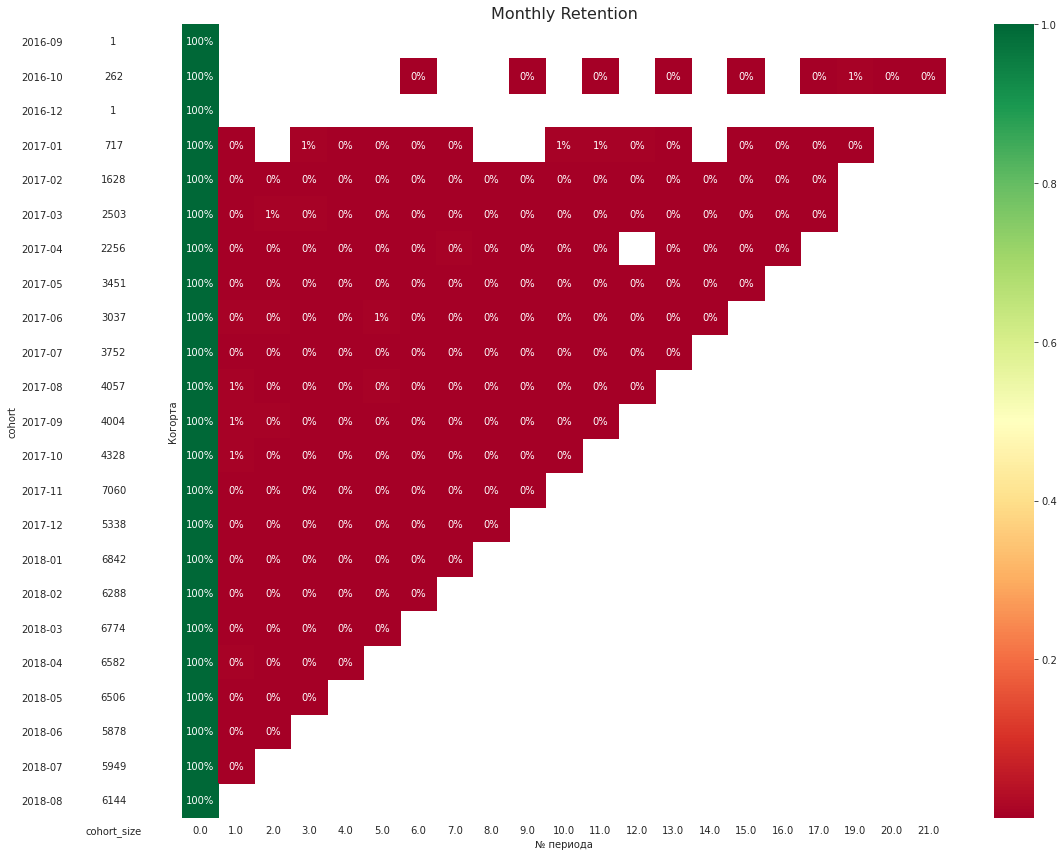

In [23]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [24]:
# Определим медианный retention 1-ого месяца
median_retention_1m = retention_matrix[1].median()
print(f'Медианный retention на 1-й месяц: {median_retention_1m:.4f}%')

Медианный retention на 1-й месяц: 0.0035%


In [25]:
print(f'Медианный количество новых пользователей в месяц: {cohort_size.median()}')

Медианный количество новых пользователей в месяц: 4057.0


In [26]:
# Найдем когорту с самым высоким retention на 3-й месяц
max_retention = retention_matrix[2.0].idxmax()
print(f'Когорта с самым высоким retention на 3-й месяц: {max_retention}')

Когорта с самым высоким retention на 3-й месяц: 2017-03


### Исходя когортного анализа данный продукт имеет слабый product/market fit.

**Привлечение новых клиентов**: Анализ данных демонстрирует, что каждый месяц в продукт `приходит значительное количество новых пользователей, с медианным значением в 4057 клиентов`. Это свидетельствует о том, что маркетплейс успешно привлекает заинтересованных клиентов, готовых совершать покупки. Именно этот постоянный приток новых пользователей позволяет бизнесу оставаться на плаву.

**Проблемы с удержанием**: Несмотря на высокий интерес со стороны новых клиентов, анализ показывает, что `в среднем только 0.3% клиентов остаются активными в первый месяц после первой покупки, а на второй месяц этот показатель стремится к нулю`. Это означает, что большинство пользователей не находят в продукте достаточной ценности для продолжения его использования. Такой высокий уровень оттока может свидетельствовать о проблемах с качеством, функциональностью или несоответствием ожиданиям клиентов.

Низкие показатели удержания могут говорить о том, что **маркетплейс недостаточно отличается от конкурентов или не предлагает клиентам значимой ценности. Возможные причины — слабая дифференциация, проблемы с качеством сервиса или отсутствие важных функций.**

В целом, текущие показатели *retention* указывают на `слабый product/market fit.` Несмотря на стабильный приток новых клиентов, низкая удерживаемость сигнализирует о `необходимости серьезных изменений в продукте и подходе к клиентскому взаимодействию.`

## 3. Проанализируем метрики продукта

In [27]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [28]:
items.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [29]:
# Изменим тип данных в колонке с датой 
items.shipping_limit_date = pd.to_datetime(items.shipping_limit_date)

In [30]:
items['shipping_limit_date'].dtypes

dtype('<M8[ns]')

In [31]:
# Объединим данные
orders_full = orders_cust.merge(items, on="order_id", how="left")
orders_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [32]:
# Приведение даты к месяцу
orders_full["order_month"] = orders_full["order_purchase_timestamp"].dt.to_period("M")
orders_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


> **1: GMV (Gross Merchandise Volume) - общий объем продаж**

*Эта метрика представляет собой совокупный объем продаж на маркетплейсе за определенный период. Она демонстрирует эффективность привлечения покупателей и способность платформы генерировать доход.*

In [33]:
GMV = orders_full.groupby("order_month")["price"].sum()
GMV.head()

order_month
2016-09       134.97
2016-10     40325.11
2016-12        10.90
2017-01    111798.36
2017-02    234223.40
Freq: M, Name: price, dtype: float64

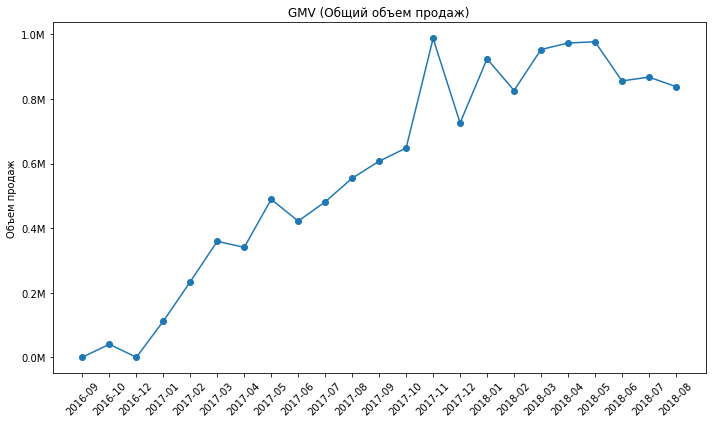

In [34]:
# Визуализируем метрику GMV
plt.figure(figsize=(10, 6))
plt.plot(GMV.index.astype(str), GMV, marker='o')
plt.title("GMV (Общий объем продаж)")

# Форматирование оси Y
formatter = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')  # Показываем в миллионах
plt.gca().yaxis.set_major_formatter(formatter)

plt.ylabel("Объем продаж")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **2: MAU - объем аудитории, которой продукт доставляет ценность - уникальные покупатели в месяц**

*Эта метрика показывает количество уникальных пользователей, которые совершают хотя бы один заказ в продукте в течение месяца. Она помогает оценить, сколько клиентов на самом деле извлекают ценность из маркетплейса, то есть находят тот товар, который им нужен.*

In [35]:
MAU = orders_full.groupby("order_month")["customer_unique_id"].nunique()

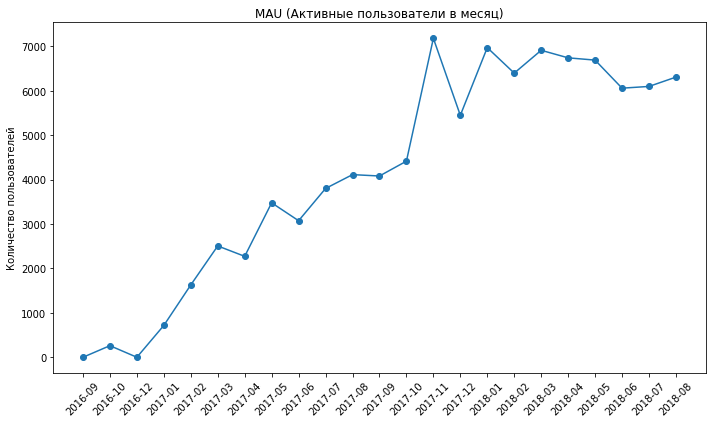

In [36]:
# Визуализируем метрику MAU
plt.figure(figsize=(10, 6))
plt.plot(MAU.index.astype(str), MAU, marker='o')
plt.title("MAU (Активные пользователи в месяц)")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **3: Конверсия в первую покупку (Conversion to Paying User) - заинтересованность новых клиентов в продукте**

*Эта метрика измеряет процент новых пользователей, которые совершают покупку после первого визита на сайт или в приложение. Она отражает, насколько эффективно маркетплейс привлекает и конвертирует новых клиентов.*

>**4: Коэффициент удержания (Retention Rate) — вовлеченность клиента в продолжение использования продукта**

*Эта метрика показывает процент клиентов, которые продолжают использовать продукт после первого месяца. Она помогает понять, насколько хорошо продукт удерживает клиентов и удовлетворяет их потребности.*

In [37]:
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN
2017-03,1.0,0.002797,0.005194,0.004395,0.001199,0.000799,0.003596,0.001598,0.002397,0.002397,...,0.001598,0.001598,0.001199,0.002797,0.000799,0.001199,0.000799,NaN,NaN,NaN
2017-04,1.0,0.003546,0.002660,0.000443,0.002660,0.003546,0.002660,0.004433,0.002216,0.002660,...,0.001330,NaN,0.000887,0.000887,0.000887,0.000887,NaN,NaN,NaN,NaN
2017-05,1.0,0.004057,0.004057,0.002318,0.003767,0.003187,0.003187,0.001159,0.002898,0.002608,...,0.003187,0.001739,0.000869,0.002028,0.001159,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004281,0.004939,0.003622,0.001646,0.005268,0.002963,0.001976,0.001317,0.003293,...,0.002963,0.000988,0.002963,0.001317,NaN,NaN,NaN,NaN,NaN,NaN


>**5: ARPU - денежное выражение вовлеченности клиента (доход на одного активного пользователя)**

*Эта метрика отражает общую выручку, которую компания получает с одного клиента в среднем*

In [38]:
revenue_user = orders_full.groupby('order_month').agg(total_revenue = ('price', 'sum'), 
                                              active_users=('customer_unique_id', 'nunique')).reset_index()

# Рассчитываем ARPU для каждого месяца
revenue_user['ARPU'] = round(revenue_user['total_revenue'] / revenue_user['active_users'], 2)

revenue_user.head()

,order_month,total_revenue,active_users,ARPU
0,2016-09,134.97,1,134.97
1,2016-10,40325.11,262,153.91
2,2016-12,10.90,1,10.90
3,2017-01,111798.36,718,155.71
4,2017-02,234223.40,1630,143.70


In [39]:
revenue_user['order_month'] = revenue_user['order_month'].astype(str)

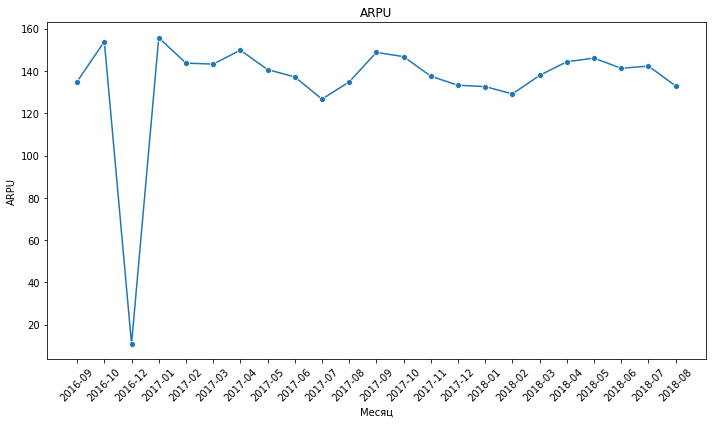

In [40]:
plt.figure(figsize=(10, 6))
sns.lineplot(x = 'order_month', y = 'ARPU', data = revenue_user, marker='o')
plt.title("ARPU")
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Выберем одну из 3 основных гипотез с помощью фреймворка ICE

> **Гипотеза 1**: Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [41]:
# Фильтрация данных с июня 2017 года
orders_june_2017 = orders_data[orders_data["order_purchase_timestamp"] >= "2017-06-01"]
orders_june_2017 = orders_june_2017.merge(customers_data[['customer_id', 'customer_unique_id']], on='customer_id', how='left')


In [42]:
# Посчитаем количество отмененных заказов (отмененными заказами будем считать статусы: canceled, unavailable)
canceled_orders = orders_june_2017[(orders_june_2017.order_status.isin(['canceled', 'unavailable']))].order_id.nunique()
print(f'Количество отмененных заказов: {canceled_orders}')


Количество отмененных заказов: 974


In [43]:
# Применяем шкалу Impact
def impact_score(canceled_orders):
    if 0 <= canceled_orders <= 50:
        return 1
    elif 51 <= canceled_orders <= 150:
        return 2
    elif 151 <= canceled_orders <= 350:
        return 3
    elif 351 <= canceled_orders <= 750:
        return 4
    elif 751 <= canceled_orders <= 1550:
        return 5
    elif 1551 <= canceled_orders <= 3150:
        return 6
    elif 3151 <= canceled_orders <= 6350:
        return 7
    elif 6351 <= canceled_orders <= 12750:
        return 8
    elif 12751 <= canceled_orders <= 25550:
        return 9
    else:
        return 10

# Вычсиляем значение Impact
impact_1 = impact_score(canceled_orders)

confidence_1 = 8
ease_1 = 6

ICE_1 = confidence_1 * ease_1 * impact_1

# Выводим результаты
print(f"Предполагаемое увеличение заказов на: {canceled_orders}")
print(f"Impact: {impact_1}")
print(f"Confidence: {confidence_1}")
print(f"Ease: {ease_1}")
print(f"ICE гипотезы 1: {ICE_1}")

Предполагаемое увеличение заказов на: 974
Impact: 5
Confidence: 8
Ease: 6
ICE гипотезы 1: 240


> **Гипотеза 2**: Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. Считаем, что мы таким образом избавимся от всех отмен.

In [44]:
# Создание столбца с годом и месяцем покупки
orders_june_2017['order_delivery_day'] = orders_june_2017['order_delivered_customer_date'].dt.to_period('D')
orders_june_2017['order_estimated_day'] = orders_june_2017['order_estimated_delivery_date'].dt.to_period('D')

In [45]:
# Посчитаем количество заказов с задержкой
delayed_orders = orders_june_2017[(orders_june_2017.order_delivery_day > orders_june_2017.order_estimated_day)
                 & (orders_june_2017.order_status.isin(['delivered']))].order_id.nunique()

In [46]:
# В данной гипотезе нас интересуют повторные заказы, поэтому будем использовать конверсию в повторный заказ
# Конверсию в повторный заказ возьмем равной 0.0035.
increase_users = delayed_orders * 0.0035

In [47]:
# Применяем шкалу Impact
def impact_score(increase_users):
    if 0 <= increase_users <= 50:
        return 1
    elif 51 <= increase_users <= 150:
        return 2
    elif 151 <= increase_users <= 350:
        return 3
    elif 351 <= increase_users <= 750:
        return 4
    elif 751 <= increase_users <= 1550:
        return 5
    elif 1551 <= increase_users <= 3150:
        return 6
    elif 3151 <= increase_users <= 6350:
        return 7
    elif 6351 <= increase_users <= 12750:
        return 8
    elif 12751 <= increase_users <= 25550:
        return 9
    else:
        return 10

# Вычисляем значение Impact
impact_2 = impact_score(increase_users)

confidence_2 = 10
ease_2 = 4

ICE_2 = confidence_2 * ease_2 * impact_2

# Выводим результаты
print(f"Предполагаемое увеличение заказов на: {round(increase_users)}")
print(f"Impact: {impact_2}")
print(f"Confidence: {confidence_2}")
print(f"Ease: {ease_2}")
print(f"ICE гипотезы 2: {ICE_2}")

Предполагаемое увеличение заказов на: 21
Impact: 1
Confidence: 10
Ease: 4
ICE гипотезы 2: 40


> **Гипотеза 3**: Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов.

*Для расчета Impact по этой гипотезе посчитаем количество заказов, где клиент сделал только единичный заказ. Конверсию в повторный заказ возьмем равной 0.0035.*

In [48]:
# Подсчитаем количество заказов для каждого клиента
customer_order_counts = orders_june_2017.groupby('customer_unique_id').order_id.nunique().reset_index()

# Определяем количество клиентов, которые сделали только один заказ
single_order_customers_count = (customer_order_counts == 1).order_id.sum()

In [49]:
customer_order_counts.groupby('order_id').nunique('customer_unique_id')

,customer_unique_id
order_id,
1,82559
2,2273
3,147
4,24
5,8
6,3
7,3
9,1
16,1


In [50]:
print(f'Количество задержанных заказов: {single_order_customers_count}')

Количество задержанных заказов: 82559


In [51]:
# Прирост заказов после внедрения нового способа оплаты
additional_orders = single_order_customers_count*0.0035

In [52]:
print(f'Возможное количество повторных заказов: {additional_orders}')

Возможное количество повторных заказов: 288.9565


In [53]:
# Применяем шкалу Impact
def impact_score(additional_orders):
    if 0 <= additional_orders <= 50:
        return 1
    elif 51 <= additional_orders <= 150:
        return 2
    elif 151 <= additional_orders <= 350:
        return 3
    elif 351 <= additional_orders <= 750:
        return 4
    elif 751 <= additional_orders <= 1550:
        return 5
    elif 1551 <= additional_orders <= 3150:
        return 6
    elif 3151 <= additional_orders <= 6350:
        return 7
    elif 6351 <= additional_orders <= 12750:
        return 8
    elif 12751 <= additional_orders <= 25550:
        return 9
    else:
        return 10

# Вычсиляем значение Impact
impact_3 = impact_score(additional_orders)

confidence_3 = 5
ease_3 = 9

ICE_3 = confidence_3 * ease_3 * impact_3

# Выводим результаты
print(f"Предполагаемое увеличение заказов на: {additional_orders}")
print(f"Impact: {impact_3}")
print(f"Confidence: {confidence_3}")
print(f"Ease: {ease_3}")
print(f"ICE гипотезы 2: {ICE_3}")

Предполагаемое увеличение заказов на: 288.9565
Impact: 3
Confidence: 5
Ease: 9
ICE гипотезы 2: 135


> **Выбираем гипотезу 1 - исправление бага, так как фреймворк выше, чем у других и равен 240, а значит это исправление должно улучшить пользовательский опыт в маркетплейсе**

## Сформулируем метрики, на которые должна повлиять выбранная гипотеза.

Для проверки гипотезы о влиянии исправления бага в системе процессинга заказов на снижение количества отмен и увеличение числа доставленных заказов необходимо определить ключевые метрики эффективности изменений. Эти метрики делятся на три категории: целевые, прокси и guardrail.

**Целевые метрики**

`Количество доставленных заказов` - общее число заказов, успешно доставленных клиентам.

*Цель: Оценить, привело ли исправление бага к увеличению успешных доставок. Это основная метрика, отражающая успех гипотезы.*

**Прокси метрики**

`Конверсия в доставку товара до покупателя` - доля доставленных заказов от общего числа оформленных заказов.

*Цель: Измерить снижение числа отмен после исправления бага и оценить эффективность обновленной системы.*

**Guardrail метрики**

`Конверсия в оформление заказа` - доля пользователей, оформивших заказ, от общего количества активных пользователей.

*Цель: Убедиться, что исправление бага не оказало негативного влияния на клиентский опыт и желание оформлять заказы.*

Эти метрики помогут объективно оценить влияние внесенных изменений и избежать возможных негативных последствий.

## Выводы и рекомендации: 

**Проблема продукта:** пользователи не возвращаются, они совершают одну/две покупки и уходят из маркетплейса.

Когортный анализ показал, что `возвращаемость` клиентов в продукт после 1-ого месяца пользования - `менее 1%`. Также видно, что каждый месяц *привлекаются новые пользователи, которые и поддерживают выручку* каждый месяц, но она стоит на месте, так как это новое кол-во пользователей **не остаются в продукте.**

Из этого следует, что у маркетплейса **нет product/market fit-а**, что говорит об *отсутствии ценности или уникальности продукта* или каких-либо *проблем с процессом оформления заказа, его доставкой или качеством*. 


Чтобы `максимизировать прибыль компании`, продакт может сконцентрироваться на следующих *5 основных метриках*: 
- **GMV** - общий объем продаж
- **MAU** - уникальные покупатели в месяц
- **Доля успешно завершенных заказов** - заинтересованность новых клиентов в продукте
- **Retention** — вовлеченность клиента в продолжение использования продукта 
- **ARPU** -  доход на одного активного пользователя

Чтобы *улучшить пользовательский опыт* в маркетплейсе и `увеличить метрики` необходимо **исправить баг в системе процессинга заказов**, тогда клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится.

Для проверки её эффективности нужно провести `A/B-тестирование`. Исправление бага должно:
-  **увеличить конверсию пользователей**
- **увеличить долю успешно доставленных заказов**
- **уменьшить доля отменённых заказов**